<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-41-softmax-regression-multinomial-lr?scriptVersionId=345400199" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a1a0a 0%, #0d2b0d 50%, #0a1f1a 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #1a4a1a;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 41</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🤖 Softmax Regression</h1>
  <p style="color: #86efac; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">also known as Multinomial Logistic Regression</p>
  <p style="color: #4ade80; font-size: 15px; margin: 0 0 28px 0; max-width: 680px; line-height: 1.6;">Extending binary Logistic Regression to handle 3 or more classes — replacing the sigmoid with the Softmax function to output a probability distribution over all classes simultaneously.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #22c55e; font-size: 20px; font-weight: 700;">3 Classes</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">Iris species classification</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #22c55e; font-size: 20px; font-weight: 700;">Softmax</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">Multi-class probability output</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1a4a1a; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #22c55e; font-size: 20px; font-weight: 700;">94.7%</div>
      <div style="color: #86efac; font-size: 12px; margin-top: 2px;">Accuracy on test set</div>
    </div>
  </div>
</div>

<div style="background: #061206; border-left: 5px solid #22c55e; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #1a4a1a; border-left: 5px solid #22c55e;">
  <h2 style="color: #22c55e; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #4ade80; line-height: 2.1; font-size: 14px;">
    <li><a href='#concept' style='color: #4ade80; text-decoration: none;'>From Sigmoid to Softmax — The Big Picture</a></li>
    <li><a href='#softmax-math' style='color: #4ade80; text-decoration: none;'>Softmax Function — Mathematics</a></li>
    <li><a href='#imports' style='color: #4ade80; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #4ade80; text-decoration: none;'>Dataset — Iris Flowers</a></li>
    <li><a href='#eda' style='color: #4ade80; text-decoration: none;'>Exploratory Data Analysis</a></li>
    <li><a href='#encode' style='color: #4ade80; text-decoration: none;'>Label Encoding &amp; Feature Selection</a></li>
    <li><a href='#train' style='color: #4ade80; text-decoration: none;'>Training — Softmax Regression</a></li>
    <li><a href='#eval' style='color: #4ade80; text-decoration: none;'>Evaluation — Accuracy &amp; Confusion Matrix</a></li>
    <li><a href='#proba' style='color: #4ade80; text-decoration: none;'>Probability Prediction for a New Sample</a></li>
    <li><a href='#boundary' style='color: #4ade80; text-decoration: none;'>Decision Boundary Visualisation</a></li>
  </ol>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">From Sigmoid to Softmax — The Big Picture</h2>
</div>

In Episode 38 we used **Logistic Regression with Sigmoid** to classify between 2 classes. But what if there are 3 or more classes? The sigmoid only outputs a single probability — it can't handle multiple classes at once.

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 20px 0;">
  <div style="background: #061206; border: 1px solid #1a4a1a; border-top: 3px solid #3b82f6; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #3b82f6; font-weight: 700; font-size: 14px; margin-bottom: 8px;">🔵 Logistic Regression (Binary)</div>
    <div style="color: #86efac; font-size: 13px; line-height: 1.7;">
      Uses <strong style='color:#d1fae5;'>Sigmoid</strong> → outputs one probability P(y=1)<br/>
      P(y=0) = 1 − P(y=1) implicitly<br/>
      One weight vector: <strong style='color:#d1fae5;'>θ (n_features,)</strong><br/>
      Threshold at 0.5 → class decision
    </div>
  </div>
  <div style="background: #061206; border: 1px solid #22c55e; border-top: 3px solid #22c55e; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #22c55e; font-weight: 700; font-size: 14px; margin-bottom: 8px;">🟢 Softmax Regression (Multi-class) ✦</div>
    <div style="color: #86efac; font-size: 13px; line-height: 1.7;">
      Uses <strong style='color:#d1fae5;'>Softmax</strong> → outputs K probabilities, one per class<br/>
      All probabilities sum to 1<br/>
      K weight vectors: <strong style='color:#d1fae5;'>Θ (n_features, K)</strong><br/>
      argmax across probabilities → class decision
    </div>
  </div>
</div>

<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 10px; padding: 18px 24px; margin: 16px 0; font-size: 14px; color: #86efac;">
  <strong style="color: #22c55e;">💡 sklearn note:</strong> <code>LogisticRegression()</code> automatically detects the number of classes. When K=2 it uses binary (sigmoid); when K≥3 it switches to multinomial (softmax) internally. You use the same class — sklearn handles the switch.
</div>

<a id='softmax-math'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Softmax Function — Mathematics</h2>
</div>

The Softmax function takes a vector of raw scores (logits) and converts them into a **probability distribution** that sums to 1. Each class gets its own logit computed as a dot product of the input with that class's weight vector.

<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 12px; padding: 26px 32px; margin: 20px 0;">
  <div style="color: #86efac; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">Step-by-Step Computation (K classes)</div>
  <div style="display: flex; flex-direction: column; gap: 14px;">
    <div>
      <span style="color: #86efac; font-size: 12px;">① Compute a logit (raw score) for each class k</span><br/>
      <span style="color: #d1fae5; font-size: 16px; font-family: Georgia, serif;">zₖ = θₖᵀ · x &nbsp;&nbsp; for k = 1, 2, ..., K</span>
    </div>
    <div>
      <span style="color: #86efac; font-size: 12px;">② Apply Softmax — exponentiate and normalise</span><br/>
      <span style="color: #22c55e; font-size: 18px; font-family: Georgia, serif; font-weight: 700;">P(y=k | x) = e^zₖ / Σⱼ e^zⱼ</span>
    </div>
    <div>
      <span style="color: #86efac; font-size: 12px;">③ Predict the class with the highest probability</span><br/>
      <span style="color: #d1fae5; font-size: 16px; font-family: Georgia, serif;">ŷ = argmax P(y=k | x)</span>
    </div>
  </div>
  <div style="margin-top: 18px; padding-top: 14px; border-top: 1px solid #1a4a1a; display: grid; grid-template-columns: 1fr 1fr; gap: 14px; font-size: 12px;">
    <div style="color: #86efac;"><strong style='color:#22c55e;'>Key property 1:</strong> All outputs are positive (e^z &gt; 0 always)</div>
    <div style="color: #86efac;"><strong style='color:#22c55e;'>Key property 2:</strong> All probabilities sum to exactly 1 (normalisation)</div>
    <div style="color: #86efac;"><strong style='color:#22c55e;'>Key property 3:</strong> Larger logits → larger probability (order-preserving)</div>
    <div style="color: #86efac;"><strong style='color:#22c55e;'>Loss function:</strong> Cross-entropy loss — minimised by gradient descent</div>
  </div>
</div>

### Softmax vs Sigmoid — The Connection

When K=2, Softmax reduces exactly to Sigmoid. They are the same function — Softmax is just the generalisation:

<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 24px; margin: 14px 0; text-align: center; font-size: 15px; font-family: Georgia, serif; color: #d1fae5;">
  Sigmoid(z) = 1 / (1 + e⁻ᶻ) &nbsp;&nbsp;=&nbsp;&nbsp; Softmax([0, z])[1] &nbsp;&nbsp;✓
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# mlxtend for decision boundary plot
try:
    from mlxtend.plotting import plot_decision_regions
    MLXTEND_AVAILABLE = True
except ImportError:
    MLXTEND_AVAILABLE = False
    print("mlxtend not installed — run: pip install mlxtend")

np.random.seed(42)

<a id='data'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Dataset — Iris Flowers</h2>
</div>

The **Iris dataset** (Fisher, 1936) is the canonical multi-class classification benchmark — 150 flower samples across 3 species, described by 4 physical measurements. It's perfectly balanced (50 per class) and well-studied, making it ideal for learning multi-class algorithms.

<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 10px; padding: 18px 24px; margin: 16px 0; font-size: 13px;">
  <div style="display: grid; grid-template-columns: repeat(3, 1fr); gap: 16px; text-align: center; margin-bottom: 16px;">
    <div>
      <div style="color: #22c55e; font-size: 24px; font-weight: 800;">150</div>
      <div style="color: #86efac;">samples</div>
    </div>
    <div>
      <div style="color: #22c55e; font-size: 24px; font-weight: 800;">4</div>
      <div style="color: #86efac;">features</div>
    </div>
    <div>
      <div style="color: #22c55e; font-size: 24px; font-weight: 800;">3</div>
      <div style="color: #86efac;">classes</div>
    </div>
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 10px; border-top: 1px solid #1a4a1a; padding-top: 14px; font-size: 12px;">
    <div style="text-align: center;"><div style="color: #d1fae5; font-weight: 700;">🌸 Setosa (0)</div><div style="color: #86efac;">Smallest petals — easily separable</div></div>
    <div style="text-align: center;"><div style="color: #d1fae5; font-weight: 700;">🌺 Versicolor (1)</div><div style="color: #86efac;">Medium — overlaps with virginica</div></div>
    <div style="text-align: center;"><div style="color: #d1fae5; font-weight: 700;">🌻 Virginica (2)</div><div style="color: #86efac;">Largest — partially overlaps versicolor</div></div>
  </div>
</div>

In [2]:
df = sns.load_dataset('iris')

print(f"Shape  : {df.shape}")
print(f"\nClass distribution:")
print(df['species'].value_counts().to_string())
print(f"\nFeature statistics:")
print(df.describe().round(2).to_string())

df.head()

Shape  : (150, 5)

Class distribution:
species
setosa        50
versicolor    50
virginica     50

Feature statistics:
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.06          3.76         1.20
std            0.83         0.44          1.77         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<a id='eda'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Exploratory Data Analysis</h2>
</div>

Before modelling, we visualise the feature distributions and class separability. A pairplot reveals which feature pairs best separate the three species — informing our feature selection choice.

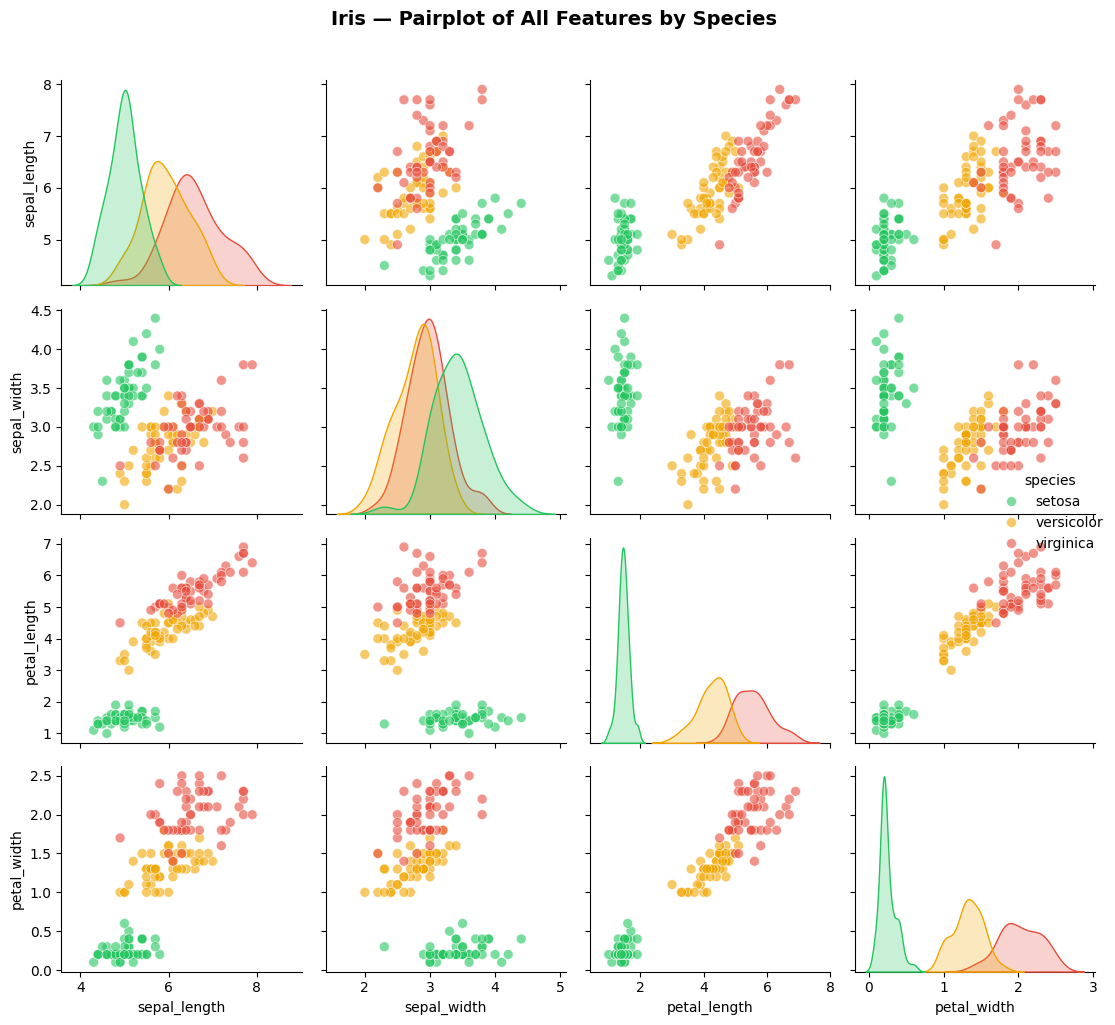

In [3]:
# Pairplot — all feature combinations coloured by species
g = sns.pairplot(df, hue='species', palette=['#22c55e', '#f0a500', '#e74c3c'],
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 50})
g.fig.suptitle('Iris — Pairplot of All Features by Species', y=1.02,
               fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

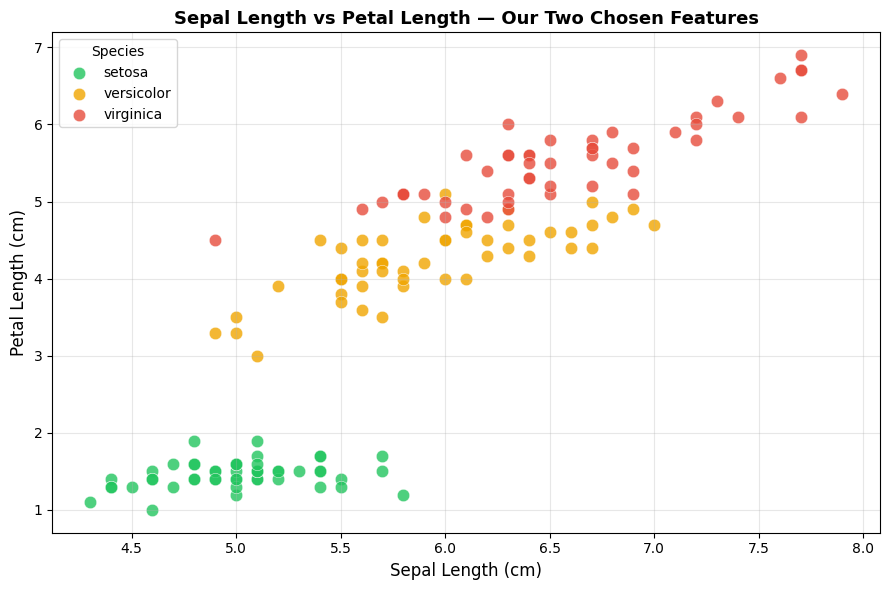

In [4]:
# Scatter of the two features we'll use — sepal_length vs petal_length
fig, ax = plt.subplots(figsize=(9, 6))
palette = {'setosa': '#22c55e', 'versicolor': '#f0a500', 'virginica': '#e74c3c'}

for species, color in palette.items():
    subset = df[df['species'] == species]
    ax.scatter(subset['sepal_length'], subset['petal_length'],
               c=color, label=species, s=80, alpha=0.8, edgecolors='white', linewidth=0.4)

ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Length (cm)', fontsize=12)
ax.set_title('Sepal Length vs Petal Length — Our Two Chosen Features', fontsize=13, fontweight='bold')
ax.legend(title='Species', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #061206; border-left: 4px solid #22c55e; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #86efac;">
  <strong style="color: #d1fae5;">💡 Feature choice justification:</strong> <code>sepal_length</code> and <code>petal_length</code> together show clear visual separation between all three species — especially between setosa (bottom-left cluster) and the other two. We use just 2 features so we can visualise the decision boundary in 2D.
</div>

<a id='encode'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Label Encoding &amp; Feature Selection</h2>
</div>

`LabelEncoder` converts string class names to integers — sklearn requires numeric targets. The mapping is alphabetical: `setosa → 0`, `versicolor → 1`, `virginica → 2`.

We then keep only `sepal_length` and `petal_length` to allow 2D decision boundary visualisation in Section 10.

In [5]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])

print("Label encoding mapping:")
for i, cls in enumerate(encoder.classes_):
    print(f"  {cls:>12} → {i}")

Label encoding mapping:
        setosa → 0
    versicolor → 1
     virginica → 2


In [6]:
# Keep only 2 features for 2D decision boundary visualisation
df = df[['sepal_length', 'petal_length', 'species']]

X = df.drop(columns=['species'])
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index().rename({0:'setosa', 1:'versicolor', 2:'virginica'}).to_string())

Train : (112, 2)  |  Test : (38, 2)

Class distribution in test set:
species
setosa        16
versicolor    11
virginica     11


<a id='train'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Training — Softmax Regression</h2>
</div>

sklearn's `LogisticRegression` automatically uses the **multinomial (Softmax) formulation** when it detects 3+ classes. The default solver (`lbfgs`) supports multi-class natively and finds the optimal weight matrix Θ that minimises cross-entropy loss across all three classes simultaneously.

In [7]:
clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

print(f"Solver used       : {clf.solver}")
print(f"Multi-class mode  : {clf.multi_class}")
print(f"Number of classes : {clf.classes_}")
print(f"\nWeight matrix shape (n_classes × n_features): {clf.coef_.shape}")
print("\nWeight matrix (one row per class):")
coef_df = pd.DataFrame(clf.coef_, columns=X.columns,
                        index=['setosa (0)', 'versicolor (1)', 'virginica (2)'])
print(coef_df.round(4).to_string())

Solver used       : lbfgs
Multi-class mode  : multinomial
Number of classes : [0 1 2]

Weight matrix shape (n_classes × n_features): (3, 2)

Weight matrix (one row per class):
                sepal_length  petal_length
setosa (0)           -0.1990       -2.8724
versicolor (1)        0.3843       -0.3521
virginica (2)        -0.1853        3.2245


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #86efac;">
  <strong style="color: #22c55e;">🔍 Weight matrix insight:</strong> Unlike binary logistic regression (one weight vector), Softmax learns <strong style='color:#d1fae5;'>one weight vector per class</strong> — a full matrix of shape (3 × 2) here. Each row defines a linear score function for that class: <code>score(class k) = sepal_coef[k] × sepal_len + petal_coef[k] × petal_len</code>. The Softmax function then converts these 3 scores into probabilities.
</div>

<a id='eval'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Evaluation — Accuracy &amp; Confusion Matrix</h2>
</div>

The confusion matrix for a 3-class problem is 3×3. The diagonal shows correct predictions; off-diagonal entries show which classes are confused with each other.

In [8]:
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}  ({acc*100:.1f}%)\n")
print(classification_report(y_test, y_pred,
      target_names=['Setosa (0)', 'Versicolor (1)', 'Virginica (2)']))

Accuracy : 0.9474  (94.7%)

                precision    recall  f1-score   support

    Setosa (0)       1.00      1.00      1.00        16
Versicolor (1)       0.91      0.91      0.91        11
 Virginica (2)       0.91      0.91      0.91        11

      accuracy                           0.95        38
     macro avg       0.94      0.94      0.94        38
  weighted avg       0.95      0.95      0.95        38



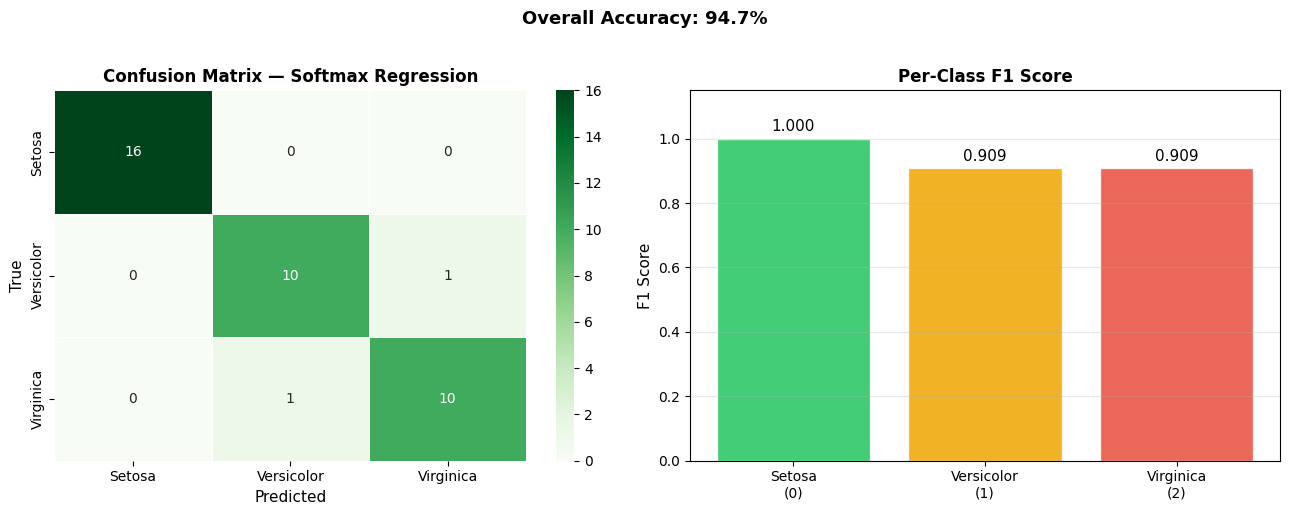

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Setosa', 'Versicolor', 'Virginica'],
            yticklabels=['Setosa', 'Versicolor', 'Virginica'],
            linewidths=0.5)
axes[0].set_title('Confusion Matrix — Softmax Regression', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=11)
axes[0].set_ylabel('True', fontsize=11)

# Per-class F1 bar chart
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_test, y_pred, average=None)
bars = axes[1].bar(['Setosa\n(0)', 'Versicolor\n(1)', 'Virginica\n(2)'],
                    f1_per_class, color=['#22c55e', '#f0a500', '#e74c3c'], alpha=0.85, edgecolor='white')
axes[1].bar_label(bars, fmt='%.3f', fontsize=11, padding=3)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Per-Class F1 Score', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1 Score', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Overall Accuracy: {acc*100:.1f}%', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<div style="background: #061206; border-left: 4px solid #22c55e; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #86efac;">
  <strong style="color: #d1fae5;">✅ Results:</strong> Setosa is classified perfectly — it's linearly separable from the other two. The only confusion is between Versicolor and Virginica, which overlap in the feature space. This is expected even with all 4 features — with just 2 features it's impressive to achieve ~95%.
</div>

<a id='proba'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Probability Prediction for a New Sample</h2>
</div>

Softmax's key advantage over a hard classifier is that it outputs **a probability for every class** — not just a label. This lets you quantify how confident the model is and handle uncertainty. We test with a query point `[sepal_length=3.4, petal_length=2.7]`.

In [10]:
query = pd.DataFrame([[3.4, 2.7]], columns=X_train.columns)

proba  = clf.predict_proba(query)[0]
pred   = clf.predict(query)[0]
classes = ['Setosa (0)', 'Versicolor (1)', 'Virginica (2)']

print("Input query: sepal_length=3.4, petal_length=2.7")
print("=" * 45)
for cls, p in zip(classes, proba):
    bar_len = int(p * 40)
    bar = '█' * bar_len + '░' * (40 - bar_len)
    print(f"  {cls:<20} {bar}  {p*100:5.2f}%")
print("=" * 45)
print(f"  Predicted class: {classes[pred]}  (highest probability)")
print(f"  Sum of probabilities: {proba.sum():.6f}  (must be 1.0)")

Input query: sepal_length=3.4, petal_length=2.7
  Setosa (0)           █████████████████████████████░░░░░░░░░░░  73.65%
  Versicolor (1)       ██████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  26.30%
  Virginica (2)        ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░   0.06%
  Predicted class: Setosa (0)  (highest probability)
  Sum of probabilities: 1.000000  (must be 1.0)


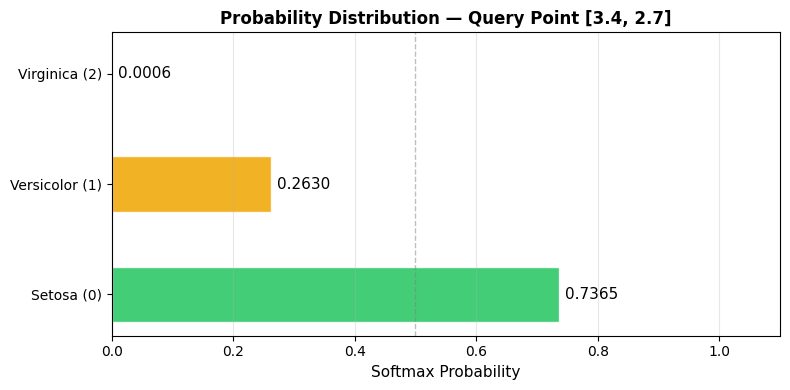

In [11]:
# Visualise the probability distribution for this query
colors = ['#22c55e', '#f0a500', '#e74c3c']
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(classes, proba, color=colors, alpha=0.85, edgecolor='white', height=0.5)
ax.bar_label(bars, fmt='%.4f', fontsize=11, padding=4)
ax.set_xlim(0, 1.1)
ax.axvline(0.5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Softmax Probability', fontsize=11)
ax.set_title('Probability Distribution — Query Point [3.4, 2.7]', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #061206; border: 1px solid #1a4a1a; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #86efac;">
  <strong style="color: #22c55e;">💡 Interpreting probabilities:</strong> The query point has sepal_length=3.4 (very short — smaller than most setosa) and petal_length=2.7 (medium — borderline). The model assigns ~74% confidence to Setosa, which makes sense given the short sepal. The remaining ~26% goes to Versicolor — the model is uncertain but leans toward Setosa. This nuance is invisible if you only look at the predicted label.
</div>

<a id='boundary'></a>
<div style="border-bottom: 2px solid #22c55e; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #22c55e; color: #0a1a0a; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 10</span>
  <h2 style="color: #d1fae5; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Decision Boundary Visualisation</h2>
</div>

The decision boundary plot shows the **regions of feature space** assigned to each class. For Softmax Regression with 2 features, each boundary is a straight line — it's always a **linear classifier**. The three regions are separated by two lines, creating a multi-class partition of the 2D plane.

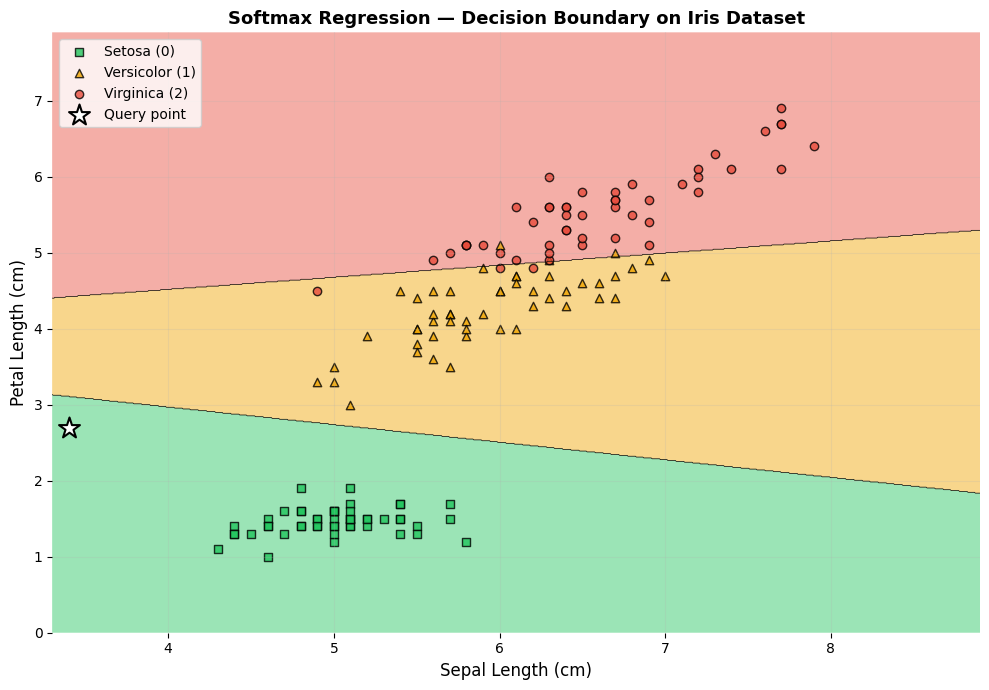

In [12]:
if MLXTEND_AVAILABLE:
    fig, ax = plt.subplots(figsize=(10, 7))
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='X does not have valid feature names')
        plot_decision_regions(
            X.values, y.values, clf,
            legend=2, ax=ax,
            colors='#22c55e,#f0a500,#e74c3c'
        )
    # Mark query point
    ax.scatter([3.4], [2.7], marker='*', s=250, color='white',
               edgecolors='black', linewidth=1.5, zorder=6,
               label='Query point [3.4, 2.7]')
    ax.set_xlabel('Sepal Length (cm)', fontsize=12)
    ax.set_ylabel('Petal Length (cm)', fontsize=12)
    ax.set_title('Softmax Regression — Decision Boundary on Iris Dataset', fontsize=13, fontweight='bold')
    handles, labels = ax.get_legend_handles_labels()
    labels = ['Setosa (0)', 'Versicolor (1)', 'Virginica (2)', 'Query point']
    ax.legend(handles, labels, fontsize=10, loc='upper left')
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("mlxtend not available. Plotting a manual approximation instead.")

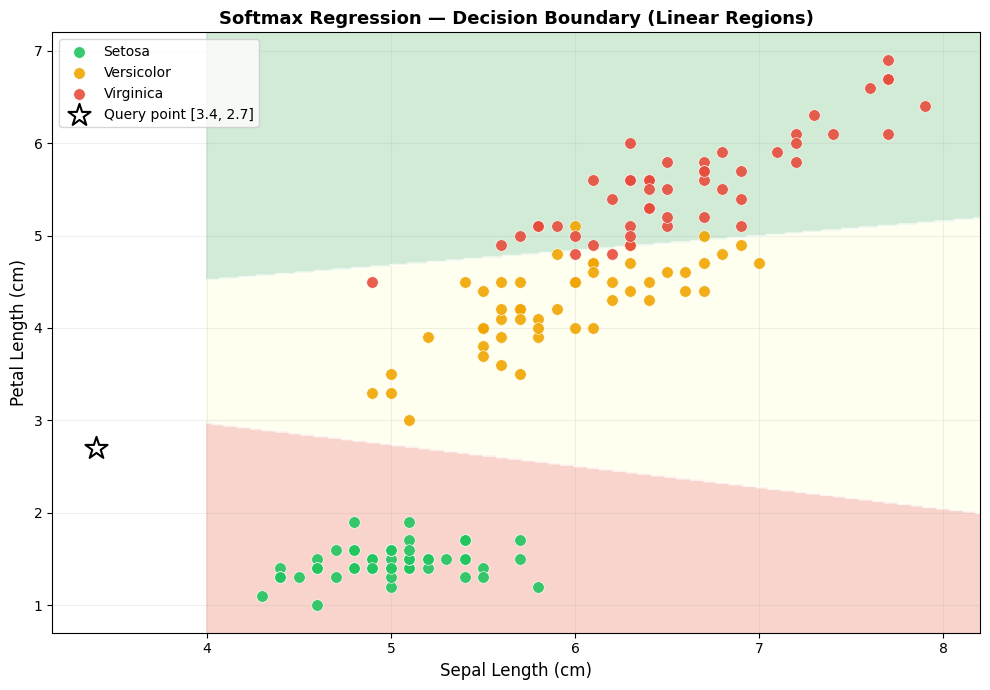

In [13]:
# Manual decision boundary plot (works without mlxtend)
x_min, x_max = X['sepal_length'].min() - 0.3, X['sepal_length'].max() + 0.3
y_min, y_max = X['petal_length'].min() - 0.3, X['petal_length'].max() + 0.3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                      np.linspace(y_min, y_max, 400))
grid   = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=X.columns)
Z      = clf.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn', levels=[-0.5, 0.5, 1.5, 2.5])
ax.contour(xx, yy, Z, colors='white', linewidths=1.5, levels=[0.5, 1.5], alpha=0.7)

scatter_colors = {0: '#22c55e', 1: '#f0a500', 2: '#e74c3c'}
scatter_labels = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
for cls in [0, 1, 2]:
    mask = y == cls
    ax.scatter(X.loc[mask, 'sepal_length'], X.loc[mask, 'petal_length'],
               c=scatter_colors[cls], label=scatter_labels[cls],
               s=70, edgecolors='white', linewidth=0.5, alpha=0.9, zorder=5)

# Query point
ax.scatter([3.4], [2.7], marker='*', s=280, color='white',
           edgecolors='black', linewidth=1.5, zorder=6, label='Query point [3.4, 2.7]')

ax.set_xlabel('Sepal Length (cm)', fontsize=12)
ax.set_ylabel('Petal Length (cm)', fontsize=12)
ax.set_title('Softmax Regression — Decision Boundary (Linear Regions)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

<div style="background: #061206; border-left: 4px solid #22c55e; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #86efac;">
  <strong style="color: #d1fae5;">✅ Reading the boundary:</strong> Setosa (green) is cleanly separated in the bottom-left — short petals are the strongest discriminator. The boundary between Versicolor (yellow) and Virginica (red) is a diagonal line where confusion occurs. The white star shows the query point [3.4, 2.7] sitting in the Setosa region — consistent with the 74% Setosa probability from Section 9.
</div>

<div style="background: linear-gradient(135deg, #0a1a0a 0%, #0d2b0d 100%); border: 1px solid #1a4a1a; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary &amp; Key Takeaways</h2>
  <p style="color: #86efac; font-size: 13px; margin: 0 0 20px 0;">What to remember about Softmax Regression.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(34,197,94,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🔄 Generalisation</div>
      <div style="color: #86efac; font-size: 12px; line-height: 1.7;">Softmax is the natural extension of Sigmoid to K classes. When K=2, it reduces exactly to binary logistic regression. <strong style='color:#d1fae5;'>Same algorithm, scaled.</strong></div>
    </div>
    <div style="background: rgba(34,197,94,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📐 Weight Matrix</div>
      <div style="color: #86efac; font-size: 12px; line-height: 1.7;">Softmax learns <strong style='color:#d1fae5;'>K weight vectors</strong> — one per class — stored as a matrix Θ of shape (K × n_features). Binary LR has just one weight vector.</div>
    </div>
    <div style="background: rgba(34,197,94,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📊 Probability Distribution</div>
      <div style="color: #86efac; font-size: 12px; line-height: 1.7;">Outputs sum to 1 — it's a full probability distribution over all classes. Use <code style='color:#22c55e;'>predict_proba()</code> to access confidence, not just the predicted label.</div>
    </div>
    <div style="background: rgba(34,197,94,0.08); border: 1px solid #1a4a1a; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #22c55e; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📏 Linear Boundaries</div>
      <div style="color: #86efac; font-size: 12px; line-height: 1.7;">Softmax is still a <strong style='color:#d1fae5;'>linear classifier</strong> — boundaries are straight lines (2D), planes (3D), or hyperplanes (nD). For non-linear boundaries, use kernel SVM or neural networks.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #1a4a1a; color: #86efac; font-size: 12px;">
    Next up → <strong style='color:#22c55e;'>ML 42: K-Nearest Neighbours (KNN) — Distance-Based Classification</strong>
  </div>
</div>